In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from phase_2.utils.paths import PROCESSED_DIR


In [2]:
FULL_UNIVERSE = [
    "SPY", "QQQ", "IWM",
    "AAPL", "MSFT", "NVDA",
    "XLU", "XLV", "XLP",
    "XLF", "XLE", "XLI",
]

data = {}

for sym in FULL_UNIVERSE:
    df = pd.read_parquet(PROCESSED_DIR / f"{sym.lower()}_daily.parquet")
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df["year"] = df["date"].dt.year
    data[sym] = df

years = sorted(data["SPY"]["year"].unique())
years[:5], years[-5:]


([np.int32(2010),
  np.int32(2011),
  np.int32(2012),
  np.int32(2013),
  np.int32(2014)],
 [np.int32(2022),
  np.int32(2023),
  np.int32(2024),
  np.int32(2025),
  np.int32(2026)])

In [3]:
# Phase 2 strategies
from phase_2.scripts.strategies.trend.trend_strategy_v1 import run_trend_strategy_v1
from phase_2.scripts.strategies.meanrev.meanrev_strategy_v1 import run_meanrev_strategy_v1

# Phase 2 meta allocator & regime features
from phase_2.scripts.strategies.meta.meta_allocator_v1 import (
    build_regime_features,
    build_meta_raw_returns_param_v1,
)

# Phase 3 gates
from phase_3.strategies.meta.strategy_gates_v1 import apply_strategy_gates
# Portfolio plumbing
from phase_2.scripts.strategies.meta.risk_targeting_v1 import apply_vol_targeting
from phase_2.scripts.strategies.portfolio.portfolio_constructor_v1 import (
    align_asset_returns,
    compute_inverse_vol_weights,
    build_portfolio_raw_returns,
)


In [4]:
HARD_PARAMS_TIGHT = {
    "trend_mom60_min": 0.0,
    "trend_mom20_min": -0.005,
    "meanrev_mom20_max": -0.025,
    "meanrev_dd60_max": -0.03,
    "meanrev_vol20_max": 0.40,
}

In [5]:
def sharpe_ratio(x: pd.Series) -> float:
    x = x.values
    if np.std(x) == 0:
        return np.nan
    return np.sqrt(252) * np.mean(x) / np.std(x)

def max_drawdown_from_returns(r: pd.Series) -> float:
    eq = (1 + r).cumprod().values
    peak = np.maximum.accumulate(eq)
    dd = eq / peak - 1.0
    return dd.min()


In [6]:
def compute_risk_contribution_snapshot(ret_wide: pd.DataFrame, weights: pd.DataFrame) -> pd.DataFrame:
    """
    Use last 252 days in ret_wide for covariance.
    Use last row of weights for portfolio weights.
    """
    asset_cols = list(ret_wide.columns)

    snapshot = ret_wide.dropna().iloc[-252:]
    cov = snapshot[asset_cols].cov()  # daily covariance

    w_last = weights.dropna().iloc[-1][asset_cols].values
    w_vec = w_last.reshape(-1, 1)

    port_var = float(w_vec.T @ cov.values @ w_vec)
    marginal = cov.values @ w_vec
    rc = (w_vec * marginal).flatten()
    rc_frac = rc / port_var

    return (
        pd.DataFrame({
            "asset": asset_cols,
            "weight": w_last,
            "risk_contribution_frac": rc_frac,
        })
        .sort_values("risk_contribution_frac", ascending=False)
        .reset_index(drop=True)
    )


In [10]:
def run_universe_walkforward(symbols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Run the full Phase 3/4 system on a given symbol universe.

    Returns:
      portfolio_daily: date, portfolio_ret, portfolio_lev, year
      ret_wide_all:   per-asset meta returns (wide)
      rc_snapshot:    risk contribution snapshot DataFrame
    """
    portfolio_all = []
    ret_wide_all = []

    for test_year in years:
        asset_daily = {}

        for sym in symbols:
            df = data[sym]
            train = df[df["year"] < test_year]
            test  = df[df["year"] == test_year]

            if len(train) < 500 or len(test) < 60:
                continue

            trend = run_trend_strategy_v1(test, train_df=train)
            meanr = run_meanrev_strategy_v1(test)
            regime = build_regime_features(test)

            trend, meanr = apply_strategy_gates(trend, meanr, regime)

            meta = build_meta_raw_returns_param_v1(
                trend,
                meanr,
                regime,
                HARD_PARAMS_TIGHT,
            )

            meta["asset"] = sym
            meta["year"] = test_year

            asset_daily[sym] = meta[["date", "asset", "year", "meta_raw_ret"]]

        if len(asset_daily) != len(symbols):
            continue

        # Align per-asset returns
        ret_wide = align_asset_returns(asset_daily)   # columns = symbols
        ret_wide_all.append(
            ret_wide.assign(year=test_year)
        )

        # Compute portfolio weights + raw returns
        w_assets = compute_inverse_vol_weights(ret_wide, lookback=20, max_weight=0.70)
        port_raw = build_portfolio_raw_returns(ret_wide, w_assets)

        # Vol targeting
        vt = apply_vol_targeting(
            port_raw,
            target_vol_annual=0.10,
            lookback=20,
            max_leverage=1.0,
        )

        portfolio_all.append(
            pd.DataFrame({
                "date": port_raw.index,
                "portfolio_ret": vt["meta_ret"].values,
                "portfolio_lev": vt["lev"].values,
                "year": test_year,
            })
        )

    portfolio_daily = (
        pd.concat(portfolio_all)
        .sort_values("date")
        .reset_index(drop=True)
    )

    ret_wide_all = pd.concat(ret_wide_all).sort_values(["date"]).reset_index(drop=True)

    # For RC snapshot, use last year only (to reflect current regime)
    last_year = portfolio_daily["year"].max()
    last_mask = ret_wide_all["year"] == last_year
    ret_last = ret_wide_all.loc[last_mask, symbols]

    # Need matching weights for that last year
    # Rebuild weights for that last year only for the snapshot
    asset_daily_last = {}
    for sym in symbols:
        df = data[sym]
        test_last = df[df["year"] == last_year]
        train_last = df[df["year"] < last_year]

        trend = run_trend_strategy_v1(test_last, train_df=train_last)
        meanr = run_meanrev_strategy_v1(test_last)
        regime = build_regime_features(test_last)
        trend, meanr = apply_strategy_gates(trend, meanr, regime)

        meta = build_meta_raw_returns_param_v1(
            trend,
            meanr,
            regime,
            HARD_PARAMS_TIGHT,
        )
        meta["asset"] = sym

        asset_daily_last[sym] = meta[["date", "asset", "meta_raw_ret"]]

    ret_wide_last = align_asset_returns(asset_daily_last)
    w_last = compute_inverse_vol_weights(ret_wide_last, lookback=20, max_weight=0.70)

    rc_snapshot = compute_risk_contribution_snapshot(ret_last, w_last)

    return portfolio_daily, ret_wide_all, rc_snapshot


In [11]:
SCENARIOS = {
    "baseline_full": FULL_UNIVERSE,
    "no_msft": [s for s in FULL_UNIVERSE if s != "MSFT"],
    "etfs_only": ["SPY", "QQQ", "IWM", "XLU", "XLV", "XLP", "XLF", "XLE", "XLI"],
    "no_mega_tech": [s for s in FULL_UNIVERSE if s not in ["MSFT", "AAPL", "NVDA"]],
}
SCENARIOS


{'baseline_full': ['SPY',
  'QQQ',
  'IWM',
  'AAPL',
  'MSFT',
  'NVDA',
  'XLU',
  'XLV',
  'XLP',
  'XLF',
  'XLE',
  'XLI'],
 'no_msft': ['SPY',
  'QQQ',
  'IWM',
  'AAPL',
  'NVDA',
  'XLU',
  'XLV',
  'XLP',
  'XLF',
  'XLE',
  'XLI'],
 'etfs_only': ['SPY', 'QQQ', 'IWM', 'XLU', 'XLV', 'XLP', 'XLF', 'XLE', 'XLI'],
 'no_mega_tech': ['SPY',
  'QQQ',
  'IWM',
  'XLU',
  'XLV',
  'XLP',
  'XLF',
  'XLE',
  'XLI']}

In [12]:
results = {}

for name, symbols in SCENARIOS.items():
    print(f"Running scenario: {name} with {len(symbols)} symbols → {symbols}")
    port, ret_wide_all, rc = run_universe_walkforward(symbols)

    # yearly summary
    rows = []
    for y, g in port.groupby("year"):
        rows.append({
            "year": y,
            "sharpe": sharpe_ratio(g["portfolio_ret"]),
            "return": (1 + g["portfolio_ret"]).prod() - 1,
            "mdd": max_drawdown_from_returns(g["portfolio_ret"]),
            "avg_lev": g["portfolio_lev"].mean(),
        })
    summary = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)

    results[name] = {
        "portfolio": port,
        "summary": summary,
        "rc": rc,
    }

    print(f"Done: {name}")


Running scenario: baseline_full with 12 symbols → ['SPY', 'QQQ', 'IWM', 'AAPL', 'MSFT', 'NVDA', 'XLU', 'XLV', 'XLP', 'XLF', 'XLE', 'XLI']


/var/folders/5x/hpfg2j9961g4st0gb95whvr80000gn/T/ipykernel_58726/1997425703.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  port_var = float(w_vec.T @ cov.values @ w_vec)


Done: baseline_full
Running scenario: no_msft with 11 symbols → ['SPY', 'QQQ', 'IWM', 'AAPL', 'NVDA', 'XLU', 'XLV', 'XLP', 'XLF', 'XLE', 'XLI']


/var/folders/5x/hpfg2j9961g4st0gb95whvr80000gn/T/ipykernel_58726/1997425703.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  port_var = float(w_vec.T @ cov.values @ w_vec)


Done: no_msft
Running scenario: etfs_only with 9 symbols → ['SPY', 'QQQ', 'IWM', 'XLU', 'XLV', 'XLP', 'XLF', 'XLE', 'XLI']


/var/folders/5x/hpfg2j9961g4st0gb95whvr80000gn/T/ipykernel_58726/1997425703.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  port_var = float(w_vec.T @ cov.values @ w_vec)


Done: etfs_only
Running scenario: no_mega_tech with 9 symbols → ['SPY', 'QQQ', 'IWM', 'XLU', 'XLV', 'XLP', 'XLF', 'XLE', 'XLI']
Done: no_mega_tech


/var/folders/5x/hpfg2j9961g4st0gb95whvr80000gn/T/ipykernel_58726/1997425703.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  port_var = float(w_vec.T @ cov.values @ w_vec)


In [13]:
# Merge all Sharpe series into one table for quick comparison
base = results["baseline_full"]["summary"][["year", "sharpe"]].rename(columns={"sharpe": "sharpe_baseline"})

tables = [base]

for name in SCENARIOS:
    if name == "baseline_full":
        continue
    s = results[name]["summary"][["year", "sharpe"]].rename(columns={"sharpe": f"sharpe_{name}"})
    tables.append(s)

cmp = tables[0]
for t in tables[1:]:
    cmp = cmp.merge(t, on="year", how="inner")

cmp


,year,sharpe_baseline,sharpe_no_msft,sharpe_etfs_only,sharpe_no_mega_tech
0,2012,1.236129,1.196136,1.466469,1.466469
1,2013,2.130349,2.254819,2.261504,2.261504
2,2014,2.592052,2.598994,2.609546,2.609546
3,2015,1.450722,1.130420,0.769653,0.769653
4,2016,2.130032,2.110982,2.024431,2.024431
5,2017,3.418010,3.303696,3.204108,3.204108
6,2018,1.229255,1.147483,0.753950,0.753950
7,2019,2.839695,2.698088,2.538963,2.538963
8,2020,3.825081,3.764259,2.734633,2.734633
9,2021,3.013777,2.907230,2.542296,2.542296


In [14]:
for name in SCENARIOS:
    print(f"\n=== Risk Contribution Snapshot: {name} ===")
    print(results[name]["rc"])



=== Risk Contribution Snapshot: baseline_full ===
   asset    weight  risk_contribution_frac
0   MSFT  0.422021                0.729195
1    SPY  0.057732                0.042765
2    QQQ  0.040055                0.037177
3   AAPL  0.056791                0.033135
4   NVDA  0.025389                0.030927
5    XLU  0.088598                0.028582
6    IWM  0.040377                0.027523
7    XLI  0.042121                0.027272
8    XLF  0.047428                0.014562
9    XLE  0.051075                0.013293
10   XLV  0.042352                0.009289
11   XLP  0.086062                0.006280

=== Risk Contribution Snapshot: no_msft ===
   asset    weight  risk_contribution_frac
0    SPY  0.099886                0.142978
1   AAPL  0.098258                0.139159
2    XLU  0.153289                0.113942
3    IWM  0.069858                0.104593
4    QQQ  0.069301                0.101430
5    XLI  0.072876                0.094105
6   NVDA  0.043928                0.078815
7

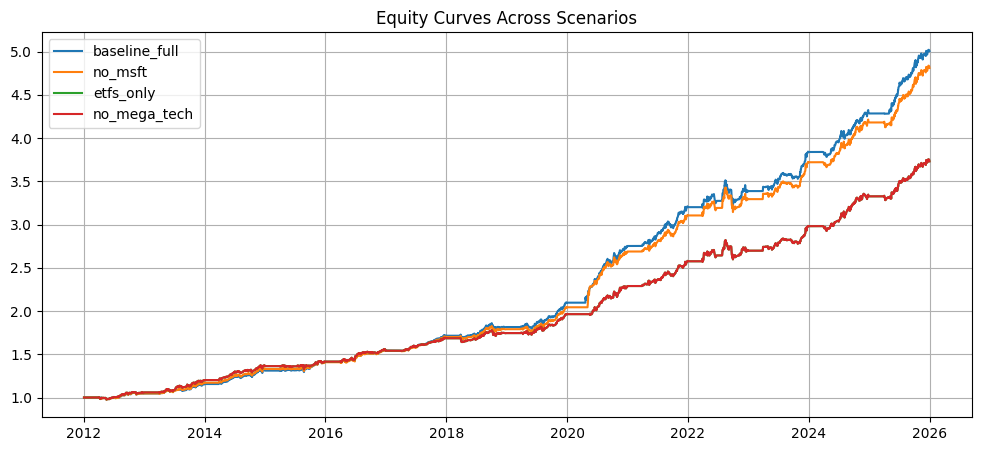

In [17]:
plt.figure(figsize=(12,5))

for name in SCENARIOS:
    port = results[name]["portfolio"]
    eq = (1 + port["portfolio_ret"]).cumprod()
    plt.plot(port["date"], eq, label=name)

plt.title("Equity Curves Across Scenarios")
plt.legend()
plt.grid(True)
plt.show()


# Summary 

## Sharpe Table
- Reveals that the systems edge is not just "MSFT as a stock" but tech beta + momentum regime
- Symstem has a broader backbone but MSFT is a big helper 

## Risk Contribution Tables
- Baseline has MSFT = 73% and everyone else = 27%
- No-Msft has risk spread across assets relatively evenly (no > 15%)
- Msft was acting as beta, trend, and factor exposure. Considered a quality/mega-cap winner. When we removed the first pricipal component, the covariance structure spreads out
- The system is not structurally dependent on MSFT (Its removal didn't cause Sharpe to collapse)

## Equity Curve
- Baseline slightly above no-msft, noticably above no mega tech 
- Matches how tech dominates the 2010-2025 regime 

We now know that the system doens't inherently require tech to function, it just rides whatever wins in that decade.